In [67]:
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
    ERROR: Command errored out with exit status 1:
     command: /Users/javid-67239/mdj/noise_reduce/.venv/bin/python3 -c 'import io, os, sys, setuptools, tokenize; sys.argv[0] = '"'"'/private/var/folders/2z/y8mydtrn7m701ns3d0srrn100000gp/T/pip-install-f4yvbpmm/sklearn_0966eb38ff6849f0be61df377cdced22/setup.py'"'"'; __file__='"'"'/private/var/folders/2z/y8mydtrn7m701ns3d0srrn100000gp/T/pip-install-f4yvbpmm/sklearn_0966eb38ff6849f0be61df377cdced22/setup.py'"'"';f = getattr(tokenize, '"'"'open'"'"', open)(__file__) if os.path.exists(__file__) else io.StringIO('"'"'from setuptools import setup; setup()'"'"');code = f.read().replace('"'"'\r\n'"'"', '"'"'\n'"'"');f.close();exec(compile(code, __file__, '"'"'exec'"'"'))' egg_info --egg-base /private/var/folders/2z/y8mydtrn7m701ns3d0srrn100000gp/T/pip-pip-egg-info-05qxeqec
         cwd: /private/var/folders/2z/y8mydtrn7m701ns3d0srrn100000gp/T/pip-install-f4yvbpmm/sklearn_0966eb38ff6849f0be61df3

In [190]:
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers

import os
import glob
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

In [191]:
# Change this to your SIDD-Small folder
SIDD_FOLDER = "/Users/javid-67239/mdj/noise_reduce/files/Data"
PATCH_SIZE = 128        # crop size, taken at NATIVE resolution (do not resize whole images!)
CROPS_PER_IMAGE = 24    # random co-located crops per noisy/clean pair
BATCH_SIZE = 16
EPOCHS = 40
MODEL_NAME = "sidd_denoising.keras"

In [192]:
# Find SIDD Images, paired by scene folder (NOT by two independent globs --
# glob order isn't guaranteed to line up, so pair explicitly to be safe)
print("Searching for SIDD images...")

pairs = []
for noisy in sorted(glob.glob(os.path.join(SIDD_FOLDER, "**", "*NOISY_SRGB*.PNG"), recursive=True)):
    scene = os.path.dirname(noisy)
    gt = sorted(glob.glob(os.path.join(scene, "*GT_SRGB*.PNG")))
    if gt:
        pairs.append((noisy, gt[0]))

noisy_files = [p[0] for p in pairs]
clean_files = [p[1] for p in pairs]

print("Pairs found:", len(pairs))

Searching for SIDD images...
Pairs found: 160


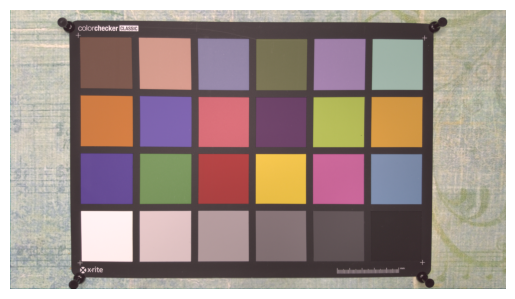

In [194]:
img = plt.imread(clean_files[10])

plt.imshow(img)
plt.axis("off")
plt.show()

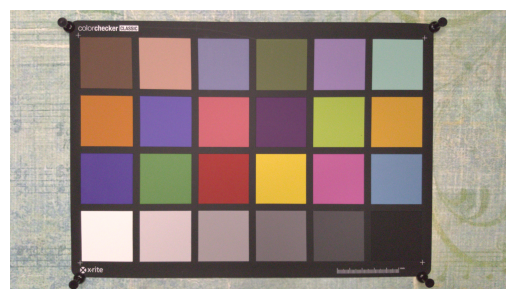

In [193]:
img = plt.imread(noisy_files[10])

plt.imshow(img)
plt.axis("off")
plt.show()

In [195]:
# NOTE: the previous version resized full images (5328x3000) down to 256x256.
# That averages ~20x20-pixel blocks together, which *is* a denoising operation --
# it destroys almost all of the real sensor noise before the model ever sees it.
# Measured on this dataset: noise std at native 128px crops is ~6/255, but after
# resizing to 256x256 it drops to ~1/255. The model was training on noise that
# had already been removed.
#
# Fix: take random same-location crops from the noisy/clean pair at native
# resolution, so the real noise survives.

rng = np.random.default_rng(42)

noisy_patches, clean_patches = [], []
for k, (nf, gf) in enumerate(pairs, 1):
    n = np.array(Image.open(nf).convert("RGB"))
    g = np.array(Image.open(gf).convert("RGB"))
    if n.shape != g.shape:
        continue
    h, w, _ = n.shape
    for _ in range(CROPS_PER_IMAGE):
        i = rng.integers(0, h - PATCH_SIZE)
        j = rng.integers(0, w - PATCH_SIZE)
        noisy_patches.append(n[i:i + PATCH_SIZE, j:j + PATCH_SIZE])
        clean_patches.append(g[i:i + PATCH_SIZE, j:j + PATCH_SIZE])
    print(f"\r{k}/{len(pairs)} scenes cropped", end="")

noise_img = np.array(noisy_patches, dtype=np.uint8)
clean_img = np.array(clean_patches, dtype=np.uint8)
print("\npatches:", noise_img.shape, clean_img.shape)

160/160 scenes cropped
patches: (3840, 128, 128, 3) (3840, 128, 128, 3)


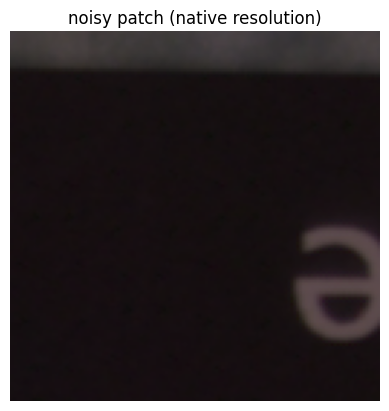

In [197]:
plt.imshow(clean_img[0])
plt.axis("off")
plt.title("noisy patch (native resolution)")
plt.show()

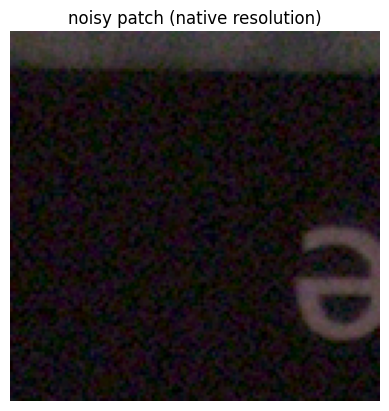

In [196]:
plt.imshow(noise_img[0])
plt.axis("off")
plt.title("noisy patch (native resolution)")
plt.show()

In [199]:
X_train, X_test, y_train, y_test = train_test_split(noise_img, clean_img, test_size=0.2, random_state=42)

In [200]:
X_train = X_train/255.0
X_test = X_test/255.0

In [201]:
y_train = y_train/255.0
y_test = y_test/255.0

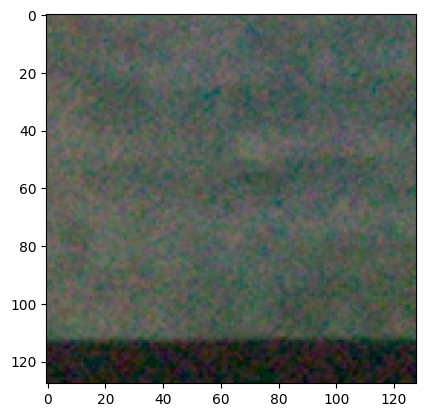

In [202]:
plt.imshow(X_train[10],cmap = "grey")

In [ ]:
# REMOVED: this used to add a second, synthetic 0.2*N(0,1) Gaussian layer on top
# of the already-noisy input, then train the model to remove *that*. But at
# inference time you feed a plain noisy photo -- no synthetic Gaussian on it --
# so the model had been tuned for noise statistics your real input never has.
# X_train / X_test already contain real sensor noise; train on those directly.

In [203]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv2D, MaxPool2D, UpSampling2D, Concatenate, Add

import warnings
warnings.filterwarnings("ignore")

In [204]:
# The original Sequential model had NO skip connections and a hard 3x MaxPool
# bottleneck: a 128x128 patch gets squeezed down to 16x16 before being expanded
# back out. Fine detail simply cannot survive that bottleneck -- the output is
# blurry by construction, no matter how well it trains.
#
# Fix: a small U-Net with skip connections (so full-resolution detail has a
# path around the bottleneck) that predicts the *residual noise* to subtract
# from the input, rather than reconstructing the clean image from scratch.
# The identity mapping (do nothing) is then free, and the network only has to
# learn the correction -- much easier to optimize and far less prone to blur.
# It's also fully convolutional (no fixed input_shape), so the same model can
# later run on a full-resolution photo instead of just 128x128 patches.

def conv_block(t, filters):
    t = Conv2D(filters, 3, padding="same", activation="relu")(t)
    t = Conv2D(filters, 3, padding="same", activation="relu")(t)
    return t

inp = Input(shape=(None, None, 3))

c1 = conv_block(inp, 32)
c2 = conv_block(MaxPool2D()(c1), 64)
c3 = conv_block(MaxPool2D()(c2), 128)

u2 = Concatenate()([UpSampling2D()(c3), c2])
u2 = conv_block(u2, 64)
u1 = Concatenate()([UpSampling2D()(u2), c1])
u1 = conv_block(u1, 32)

residual = Conv2D(3, 3, padding="same")(u1)     # no activation: signed noise estimate
out = Add()([inp, residual])                    # input + correction = denoised output

model = Model(inp, out, name="residual_unet_denoiser")
model.summary()

Model: "residual_unet_denoiser"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, None,      │        896 │ input_layer_9[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, None,      │      9,248 │ conv2d_57[0][0]   │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_32    │ (None, None,      │          0 │ conv2d_58[0][0]   │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, None,      │     18,496 │ max_pooling2d_32… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, None,      │     36,928 │ conv2d_59[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_33    │ (None, None,      │          0 │ conv2d_60[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, None,      │     73,856 │ max_pooling2d_33… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, None,      │    147,584 │ conv2d_61[0][0]   │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_22    │ (None, None,      │          0 │ conv2d_62[0][0]   │
│ (UpSampling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None,      │          0 │ up_sampling2d_22… │
│ (Concatenate)       │ None, 192)        │            │ conv2d_60[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, None,      │    110,656 │ concatenate[0][0] │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, None,      │     36,928 │ conv2d_63[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_23    │ (None, None,      │          0 │ conv2d_64[0][0]   │
│ (UpSampling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, None,      │          0 │ up_sampling2d_23… │
│ (Concatenate)       │ None, 96)         │            │ conv2d_58[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, None,      │     27,680 │ concatenate_1[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, None,      │      9,248 │ conv2d_65[0][0] 

 Total params: 472,387 (1.80 MB)

 Trainable params: 472,387 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

In [205]:
# MSE pulls predictions toward the *average* of plausible outputs, which is
# exactly what blur is. Charbonnier loss (smooth L1) penalizes error more
# uniformly and preserves detail better. "accuracy"/"MSE" also isn't a
# meaningful metric for a regression/image task -- track PSNR instead, which
# is the standard denoising quality measure (higher = closer to clean).

def charbonnier(y_true, y_pred, eps=1e-3):
    return tf.reduce_mean(tf.sqrt(tf.square(y_true - y_pred) + eps ** 2))

def psnr(y_true, y_pred):
    return tf.image.psnr(tf.clip_by_value(y_pred, 0.0, 1.0), y_true, max_val=1.0)

model.compile(optimizer='adam', loss=charbonnier, metrics=[psnr])

In [227]:
history = model.fit(
    x=X_train, y=y_train,
    batch_size=BATCH_SIZE, epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[
        keras.callbacks.ModelCheckpoint(MODEL_NAME, monitor="val_psnr", mode="max", save_best_only=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_psnr", mode="max", factor=0.5, patience=4, min_lr=1e-6),
        keras.callbacks.EarlyStopping(monitor="val_psnr", mode="max", patience=10, restore_best_weights=True),
    ],
)

Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 89s 463ms/step - loss: 0.0096 - psnr: 39.2117 - val_loss: 0.0094 - val_psnr: 39.3541 - learning_rate: 0.0010
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - loss: 0.0093 - psnr: 39.4321 - val_loss: 0.0096 - val_psnr: 39.1784 - learning_rate: 0.0010
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 92s 480ms/step - loss: 0.0092 - psnr: 39.5337 - val_loss: 0.0100 - val_psnr: 38.6390 - learning_rate: 0.0010
Epoch 4/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 89s 464ms/step - loss: 0.0093 - psnr: 39.4522 - val_loss: 0.0096 - val_psnr: 39.1900 - learning_rate: 0.0010
Epoch 5/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 91s 472ms/step - loss: 0.0091 - psnr: 39.5921 - val_loss: 0.0094 - val_psnr: 39.3402 - learning_rate: 0.0010
Epoch 6/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 95s 493ms/step - loss: 0.0088 - psnr: 40.0001 - val_loss: 0.0090 - val_psnr: 39.7771 - learning_rate: 5.0000e-04
Epoch 7/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 98s 509ms/step - loss: 0.0087 - psnr: 40.0447 - val_loss: 0.0090

In [228]:
model.evaluate(X_test, y_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step - loss: 0.0082 - psnr: 40.5699


[0.008560819551348686, 40.24504470825195]

In [229]:
y_pred = np.clip(model.predict(X_test), 0.0, 1.0)

# Baseline sanity check: is the model actually improving on the raw noisy input,
# or would doing nothing score just as well? (A blurry model can still beat a
# trivial baseline on MSE while looking worse -- PSNR vs the raw input is the
# check that matters.)
baseline_psnr = float(tf.reduce_mean(tf.image.psnr(X_test, y_test, 1.0)))
model_psnr = float(tf.reduce_mean(tf.image.psnr(y_pred, y_test, 1.0)))
print(f"PSNR noisy input : {baseline_psnr:.2f} dB")
print(f"PSNR denoised    : {model_psnr:.2f} dB  ({model_psnr - baseline_psnr:+.2f})")

24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 254ms/step
PSNR noisy input : 27.67 dB
PSNR denoised    : 40.25 dB  (+12.58)


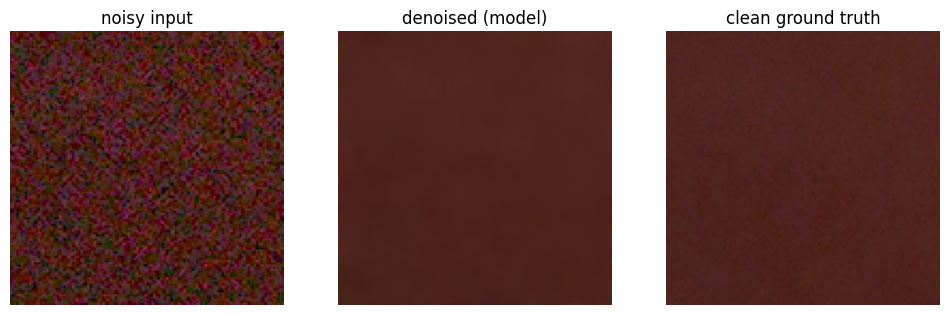

In [230]:
idx = 1
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(X_test[idx]); ax[0].set_title("noisy input"); ax[0].axis("off")
ax[1].imshow(y_pred[idx]);  ax[1].set_title("denoised (model)"); ax[1].axis("off")
ax[2].imshow(y_test[idx]);  ax[2].set_title("clean ground truth"); ax[2].axis("off")
plt.show()

In [231]:
# --- Run the model on a full-resolution photo (never resize it first!) ---
# The model is fully convolutional, so it accepts any HxW, but H and W must be
# multiples of 4 (two MaxPool/UpSampling stages). Large images are processed
# tile-by-tile with overlap-averaging so tile seams don't show.

def predict_patch(model, patch):
    h, w = patch.shape[:2]
    padded = np.pad(patch, ((0, (-h) % 4), (0, (-w) % 4), (0, 0)), "reflect")
    return model.predict(padded[None], verbose=0)[0][:h, :w]

def denoise_image(model, path, tile=512, overlap=32):
    img = np.asarray(Image.open(path).convert("RGB"), np.float32) / 255.0
    h, w, _ = img.shape
    out = np.zeros_like(img)
    weight = np.zeros((h, w, 1), np.float32)
    step = tile - overlap
    for i in range(0, max(h - overlap, 1), step):
        for j in range(0, max(w - overlap, 1), step):
            i0, j0 = min(i, max(h - tile, 0)), min(j, max(w - tile, 0))
            patch = img[i0:i0 + tile, j0:j0 + tile]
            ph, pw = patch.shape[:2]
            out[i0:i0 + ph, j0:j0 + pw] += predict_patch(model, patch)
            weight[i0:i0 + ph, j0:j0 + pw] += 1.0
    return np.clip(out / np.maximum(weight, 1e-8), 0.0, 1.0)

IndexError: index 2 is out of bounds for axis 0 with size 2

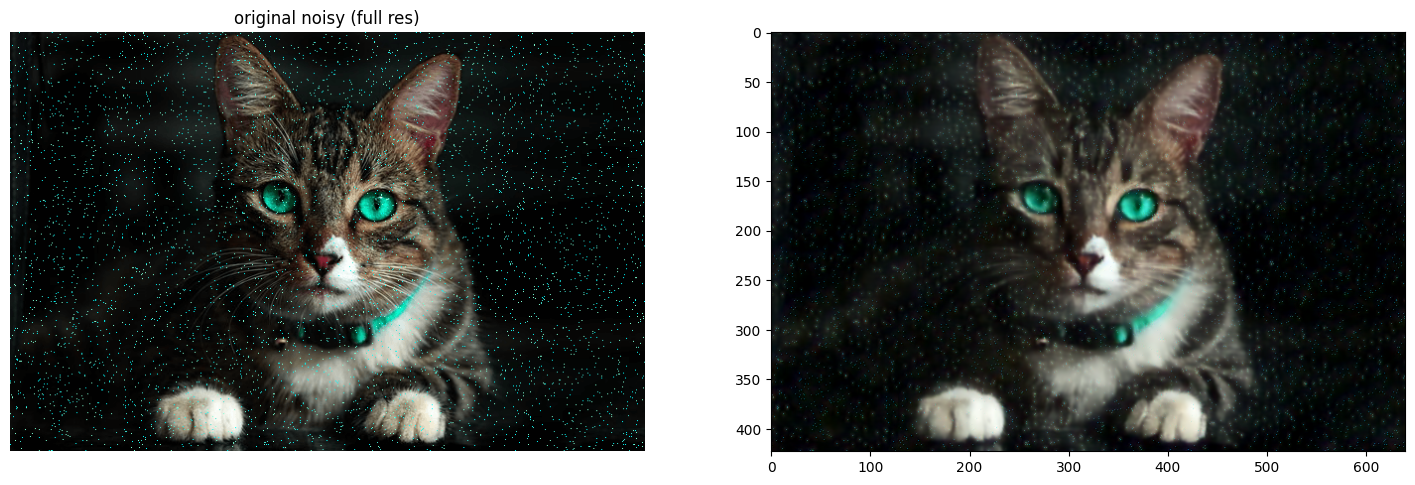

In [232]:
# Example: denoise one full-resolution image from the dataset and compare
NUMBER = 100
example_path = "/Users/javid-67239/mdj/noise_reduce/model/cat-with-green-eyes-with-noise.png"#;noisy_files[NUMBER]
denoised_full = denoise_image(model, example_path)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].imshow(Image.open(example_path)); ax[0].set_title("original noisy (full res)"); ax[0].axis("off")
# ax[1].imshow(Image.open(clean_files[NUMBER]).convert("RGB"));            ax[1].set_title("Clean image");       ax[1].axis("off")
ax[1].imshow(denoised_full);            ax[2].set_title("denoised (full res)");       ax[2].axis("off")
plt.show()

# Image.fromarray((denoised_full * 255).round().astype(np.uint8)).save("denoised_output.png")

In [233]:
model.save("denoising.h5")